<a href="https://colab.research.google.com/github/ashishkhetwal/Car-Price-Prediction/blob/main/Car_Price_Prediction_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
car_dataset = pd.read_csv('/content/car data.csv')

In [104]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [105]:
car_dataset.shape

(301, 9)

In [106]:
car_dataset.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [107]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [108]:
car_dataset.isnull().sum().sum()

np.int64(0)

In [109]:
car_dataset['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [110]:
car_dataset['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [111]:
car_dataset['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


Label Encoding

0-> petrol , 1 ->diesel, 2->cng

0-> dealer, 1->individual

0-> manual, 1->automatic

In [112]:
#encoding the fuel type
car_dataset.replace({'Fuel_Type':{'Petrol' : 0, 'Diesel' : 1, 'CNG' : 2}}, inplace = True)

/tmp/ipykernel_1688/2690970917.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Fuel_Type':{'Petrol' : 0, 'Diesel' : 1, 'CNG' : 2}}, inplace = True)


In [113]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,1,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,0,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,0,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,1,Dealer,Manual,0


In [114]:
car_dataset.replace({'Seller_Type': {'Dealer' : 0, 'Individual' : 1}}, inplace = True)
car_dataset.replace({'Transmission': {'Manual' : 0, 'Automatic' : 1}}, inplace = True)

/tmp/ipykernel_1688/2489757661.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Seller_Type': {'Dealer' : 0, 'Individual' : 1}}, inplace = True)
/tmp/ipykernel_1688/2489757661.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Transmission': {'Manual' : 0, 'Automatic' : 1}}, inplace = True)


In [115]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [116]:
#Separating the labels and data
X = car_dataset.drop(['Car_Name', 'Selling_Price'], axis = 1)
Y = car_dataset['Selling_Price']

Splitting the data into training and testing

In [117]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [118]:
X_train.shape

(240, 7)

In [119]:
X_test.shape

(61, 7)

Model Training

In [120]:
lin_reg_model = LinearRegression()

In [121]:
lin_reg_model.fit(X_train, Y_train)

LinearRegression()

Evaluation

In [122]:
#using R squared error
train_data_prediction = lin_reg_model.predict(X_train)
error_score = metrics.r2_score(Y_train, train_data_prediction)
print("R squared error : ", error_score)


R squared error :  0.8838169193709796


Visualize the actual price vs predicted price

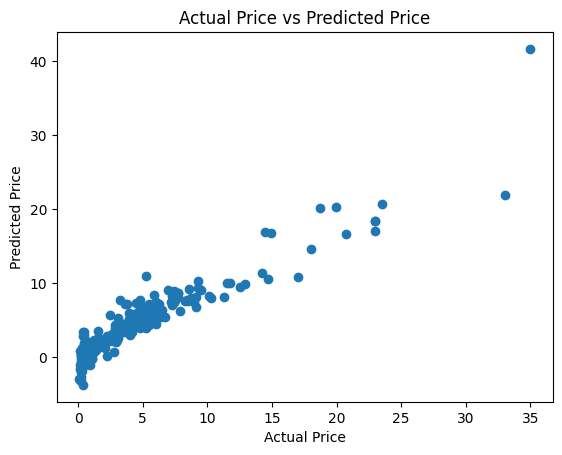

In [126]:
plt.scatter(x= Y_train, y = train_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

Evaluate using Test data

In [127]:
#using R squared error
test_data_prediction = lin_reg_model.predict(X_test)
error_score_test = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ", error_score_test)


R squared error :  0.8401532365377697


Visualize using test data

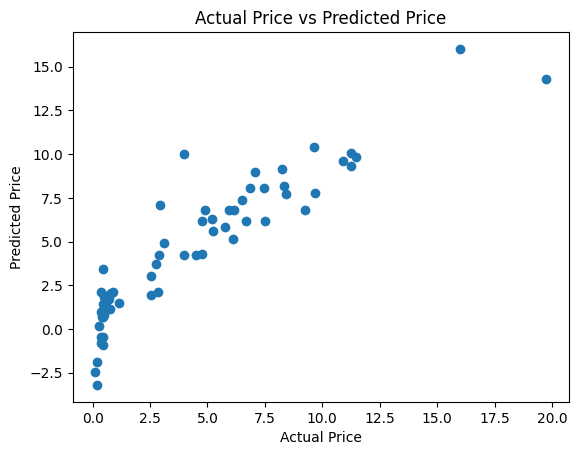

In [128]:
plt.scatter(x= Y_test, y = test_data_prediction)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

Now comparing with Lasso Regression

In [129]:
lasso_reg_model = Lasso()

In [130]:
lasso_reg_model.fit(X_train, Y_train)

Lasso()

In [131]:
train_data_prediction_lasso = lasso_reg_model.predict(X_train)
error_score_lasso = metrics.r2_score(Y_train, train_data_prediction_lasso)
print("R squared error : ", error_score_lasso)

R squared error :  0.843587395258283


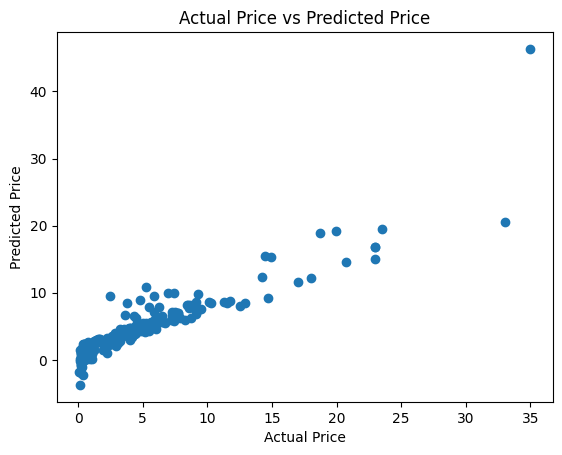

In [132]:
#plotting using scatter plot
plt.scatter(x= Y_train, y = train_data_prediction_lasso)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()

In [133]:
#now on test data
test_data_prediction_lasso = lasso_reg_model.predict(X_test)
error_score_lasso = metrics.r2_score(Y_test, test_data_prediction_lasso)
print("R squared error : ", error_score_lasso)

R squared error :  0.8497457570738539


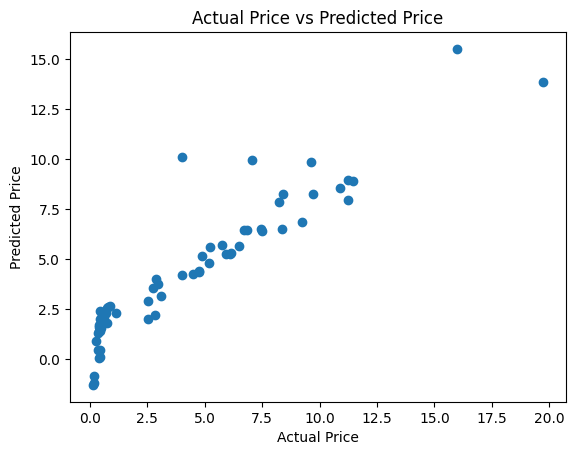

In [136]:
#visualize using scatter
plt.scatter(x= Y_test, y = test_data_prediction_lasso)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")
plt.show()